# Demo 3: Advanced Feature Extraction from Heart Rate Variability Data

This notebook guides you through advanced feature extraction from RR interval data. Each section is annotated with visible context and teaching notes for health data science beginners.

## 1. Setup: Import Libraries and Configure Environment

**Teaching Note:**  
Importing libraries is the first step in any data science workflow. Here, we use pandas and numpy for data manipulation, matplotlib and seaborn for plotting, and statsmodels/scipy for time series and signal processing. Setting a random seed ensures reproducibility.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal
import os
import glob
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 2. Load and Explore Patient Metadata

**Teaching Note:**  
Patient metadata provides context for the physiological data. Age groupings are useful for stratified analysis.

In [100]:
data_dir = 'rr-interval-time-series-from-healthy-subjects-1.0.0'
patient_info = pd.read_csv(f'{data_dir}/patient-info.csv')
print(f"Loaded information for {len(patient_info)} patients")
print(patient_info.head())

Loaded information for 147 patients
   File  Age (years) Gender
0     0         53.0      M
1     2         17.0      F
2     3         46.0      F
3     5         38.0      F
4     6         32.0      M


### Explore Patient Age Distribution

**Teaching Note:**  
Visualizing age distribution helps understand the diversity of the dataset and informs later analysis.

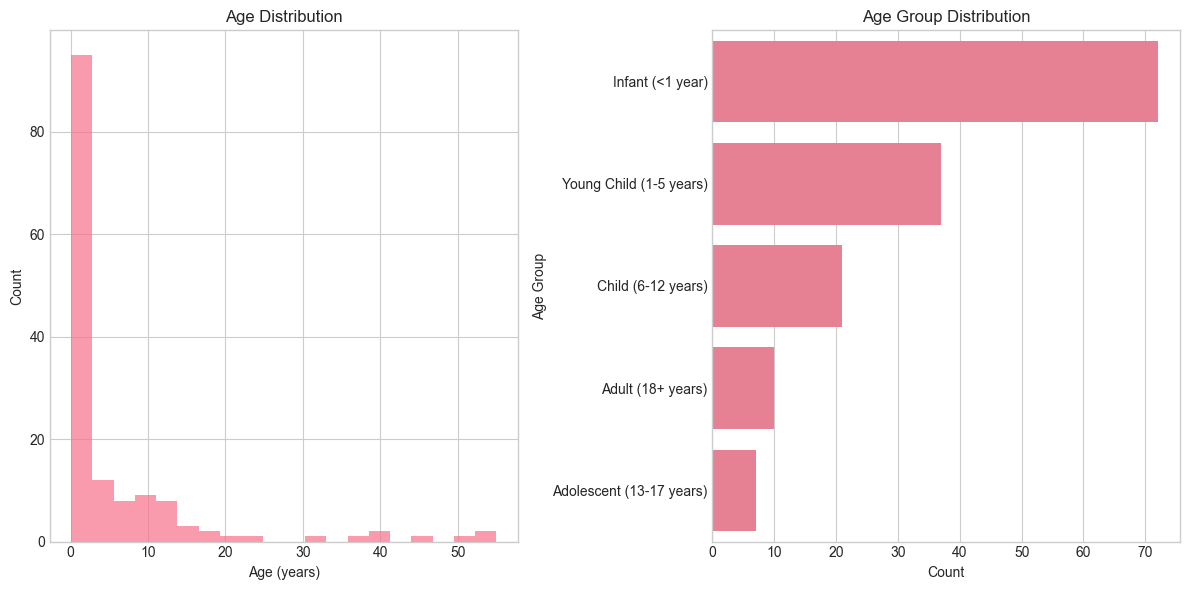

In [101]:
def categorize_age(age):
    if age < 1:
        return "Infant (<1 year)"
    elif age < 6:
        return "Young Child (1-5 years)"
    elif age < 13:
        return "Child (6-12 years)"
    elif age < 18:
        return "Adolescent (13-17 years)"
    else:
        return "Adult (18+ years)"
patient_info['Age Group'] = patient_info['Age (years)'].apply(categorize_age)
age_group_counts = patient_info['Age Group'].value_counts()
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(patient_info['Age (years)'], bins=20, alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.grid(True)
plt.subplot(1, 2, 2)
sns.countplot(y='Age Group', data=patient_info, order=age_group_counts.index)
plt.title('Age Group Distribution')
plt.xlabel('Count')
plt.ylabel('Age Group')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

## 3. Load and Process RR Interval Data

**Teaching Note:**  
RR intervals (the time between heartbeats) are often irregularly sampled. Preprocessing and visualizing helps spot artifacts and physiological patterns.

In [102]:
def load_rr_intervals(file_path):
    with open(file_path, 'r') as f:
        rr_intervals = [float(line.strip()) for line in f if line.strip()]
    return np.array(rr_intervals)

selected_patients = []
for age_group in age_group_counts.index:
    group_patients = patient_info[patient_info['Age Group'] == age_group].head(2)
    selected_patients.extend(group_patients['File'].tolist())

rr_data = {}
for patient_id in selected_patients:
    file_path = f'{data_dir}/{patient_id:03d}.txt'
    if os.path.exists(file_path):
        rr_data[patient_id] = load_rr_intervals(file_path)
        print(f"Loaded {len(rr_data[patient_id])} RR intervals for patient {patient_id}")

Loaded 171328 RR intervals for patient 4000
Loaded 185563 RR intervals for patient 4001
Loaded 105037 RR intervals for patient 404
Loaded 153896 RR intervals for patient 4002
Loaded 99188 RR intervals for patient 401
Loaded 89743 RR intervals for patient 402
Loaded 80441 RR intervals for patient 0
Loaded 108150 RR intervals for patient 3
Loaded 68029 RR intervals for patient 2
Loaded 110511 RR intervals for patient 11


### Preprocess and Visualize RR Intervals

**Teaching Note:**  
Preprocessing removes outliers and ectopic beats. Visualizing before and after helps students see the impact of cleaning.

Preprocessed RR intervals for patient 4000: 171044 intervals
Preprocessed RR intervals for patient 4001: 179914 intervals
Preprocessed RR intervals for patient 404: 104717 intervals
Preprocessed RR intervals for patient 4002: 150102 intervals
Preprocessed RR intervals for patient 401: 96030 intervals
Preprocessed RR intervals for patient 402: 78408 intervals
Preprocessed RR intervals for patient 0: 79918 intervals
Preprocessed RR intervals for patient 3: 107622 intervals
Preprocessed RR intervals for patient 2: 66917 intervals
Preprocessed RR intervals for patient 11: 109825 intervals


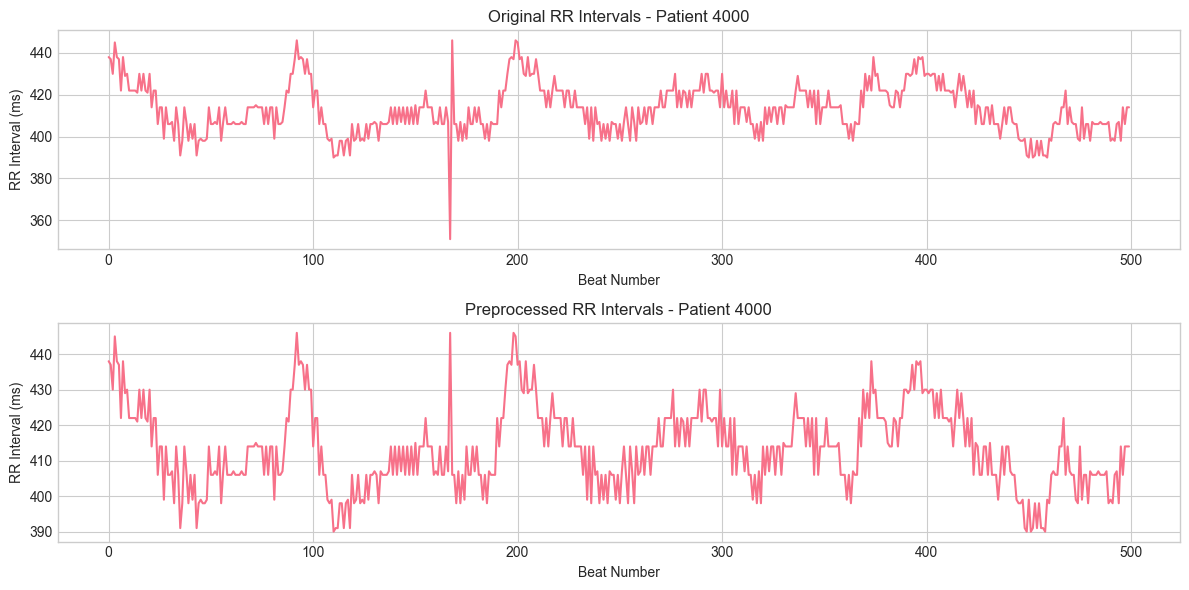

In [103]:
def preprocess_rr(rr_intervals, remove_outliers=True, remove_ectopic=True):
    rr = np.array(rr_intervals)
    if remove_outliers:
        mean_rr = np.mean(rr)
        std_rr = np.std(rr)
        rr = rr[(rr > mean_rr - 3*std_rr) & (rr < mean_rr + 3*std_rr)]
    if remove_ectopic:
        rr_diff = np.abs(np.diff(rr) / rr[:-1])
        good_indices = np.where(rr_diff < 0.2)[0]
        rr = rr[good_indices]
    return rr

preprocessed_rr = {}
for patient_id, rr in rr_data.items():
    preprocessed_rr[patient_id] = preprocess_rr(rr)
    print(f"Preprocessed RR intervals for patient {patient_id}: {len(preprocessed_rr[patient_id])} intervals")

sample_patient = list(preprocessed_rr.keys())[0]
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(rr_data[sample_patient][:500])
plt.title(f'Original RR Intervals - Patient {sample_patient}')
plt.xlabel('Beat Number')
plt.ylabel('RR Interval (ms)')
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(preprocessed_rr[sample_patient][:500])
plt.title(f'Preprocessed RR Intervals - Patient {sample_patient}')
plt.xlabel('Beat Number')
plt.ylabel('RR Interval (ms)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Feature Extraction from RR Intervals

Feature extraction is like turning a long, messy list of numbers into a set of meaningful "health signals" that we can use for analysis, prediction, or even machine learning. In heart rate variability (HRV) research, these features help us understand how the autonomic nervous system is regulating the heart—think of it as a window into stress, recovery, and overall health.

We'll walk through three key steps:
- **Time-domain features:** Simple statistics that summarize the RR intervals.
- **Frequency-domain features (FFT):** Reveal hidden rhythms and periodicities in the data.
- **Bandpass filtering:** Focus on the most physiologically relevant frequency bands.


### 4.1 Time-Domain Features

Time-domain features are the "vital signs" of HRV analysis. They summarize the basic statistical properties of the RR intervals, such as average, spread, and extremes. These are easy to interpret and often used in clinical research.

In [104]:
# Let's extract some basic statistics from one patient's preprocessed RR intervals.
# These numbers help us quickly summarize the "shape" of the heart rate signal.

# Select a sample patient's preprocessed RR intervals
sample_patient = list(preprocessed_rr.keys())[0]
rr = preprocessed_rr[sample_patient]

# Calculate time-domain features
mean_rr = np.mean(rr)
std_rr = np.std(rr)
median_rr = np.median(rr)
min_rr = np.min(rr)
max_rr = np.max(rr)
print(f"Mean RR: {mean_rr:.2f} ms")
print(f"STD RR: {std_rr:.2f} ms")
print(f"Median RR: {median_rr:.2f} ms")
print(f"Min RR: {min_rr:.2f} ms")
print(f"Max RR: {max_rr:.2f} ms")

# Output explanation:
# - Mean RR: The average time between heartbeats (lower = faster heart rate).
# - STD RR: How much the intervals vary (higher = more variability).
# - Median, Min, Max: Useful for spotting outliers or unusual patterns.

Mean RR: 446.30 ms
STD RR: 55.72 ms
Median RR: 430.00 ms
Min RR: 304.00 ms
Max RR: 610.00 ms


### 4.2 Frequency-Domain Features (FFT)

Time-domain features are great, but sometimes the most interesting patterns are hidden in the "rhythms" of the data. Frequency-domain analysis lets us see these rhythms—like how breathing or stress affects heart rate—by breaking the signal into its component frequencies. The Fast Fourier Transform (FFT) is our microscope for this job.

In [105]:
# To analyze frequencies, we need to know the "sampling rate" of our data.
# For RR intervals, this is the average number of heartbeats per second.

# Estimate the sampling rate (approximate, since RR intervals are in ms)
sampling_rate = 1000 / np.mean(rr)  # Hz
print(f"Estimated sampling rate: {sampling_rate:.2f} Hz")

# The FFT (Fast Fourier Transform) requires evenly spaced data.
# We'll interpolate the RR intervals to create a regularly sampled signal.

# Interpolate RR intervals to get evenly spaced samples for FFT
from scipy.interpolate import interp1d
time = np.cumsum(rr) / 1000  # seconds
uniform_time = np.arange(0, time[-1], 1/sampling_rate)
interp_func = interp1d(time, rr, kind='linear', fill_value='extrapolate')
rr_uniform = interp_func(uniform_time)
print(f"Uniformly sampled RR signal length: {len(rr_uniform)}")

Estimated sampling rate: 2.24 Hz
Uniformly sampled RR signal length: 171044


Now let's look for hidden rhythms in the heart rate signal using FFT.
The plot will show which frequencies (cycles per second) are most prominent.


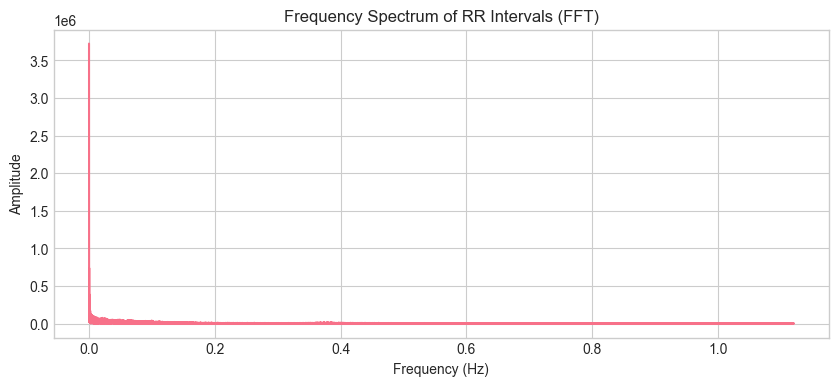

In [106]:
# Compute FFT
from scipy.fft import fft, fftfreq
yf = fft(rr_uniform - np.mean(rr_uniform))  # Remove mean for clearer spectrum
xf = fftfreq(len(rr_uniform), 1/sampling_rate)

# Plot frequency spectrum
plt.figure(figsize=(10, 4))
plt.plot(xf[1:len(xf)//2], np.abs(yf[1:len(yf)//2]))
plt.title('Frequency Spectrum of RR Intervals (FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

#### Output explanation:
- Peaks in the plot indicate dominant rhythms (e.g., breathing, stress response).
- The x-axis is frequency in Hz; the y-axis is the strength of that rhythm.
- This graph isn't very interesting due to the clustering at zero, so we'll have to do some filtering first...

### 4.3 Bandpass Filtering for HRV Analysis

Not all frequencies in our signal are equally important for health analysis. Bandpass filtering is like tuning a radio to the stations you care about—in HRV, we focus on the LF (low frequency) and HF (high frequency) bands, which are linked to different branches of the nervous system. Filtering helps us remove noise and focus on the most meaningful physiological rhythms.

Bandpass filtering is an important step in HRV analysis because it allows us to focus on the frequency ranges that are most relevant to physiological processes. In particular, the LF (0.04–0.15 Hz) and HF (0.15–0.4 Hz) bands are associated with different aspects of autonomic nervous system function. By filtering out frequencies outside this range, we reduce noise and make our analysis more meaningful, especially when comparing HRV across individuals or conditions.

In [107]:
# To focus on the most meaningful physiological rhythms, we'll apply a bandpass filter.
# This keeps only the frequencies in the typical HRV range (0.04–0.4 Hz).

# Design a Butterworth bandpass filter for 0.04–0.4 Hz
from scipy.signal import butter, filtfilt

lowcut = 0.04
highcut = 0.4
nyquist = 0.5 * sampling_rate
low = lowcut / nyquist
high = highcut / nyquist

b, a = butter(N=4, Wn=[low, high], btype='band')
rr_filtered = filtfilt(b, a, rr_uniform)

#### Visualizing the Effect of Bandpass Filtering

After applying the bandpass filter, it's helpful to plot both the original and filtered RR interval signals. This allows us to see how the filter removes noise and highlights the main HRV rhythms. The filtered signal should appear smoother, making it easier to interpret the physiological patterns of interest.

**Note:** The bandpass filter removes slow trends and the mean value from the RR signal, so the filtered signal is centered around zero. This is normal and highlights only the oscillatory (HRV) components.

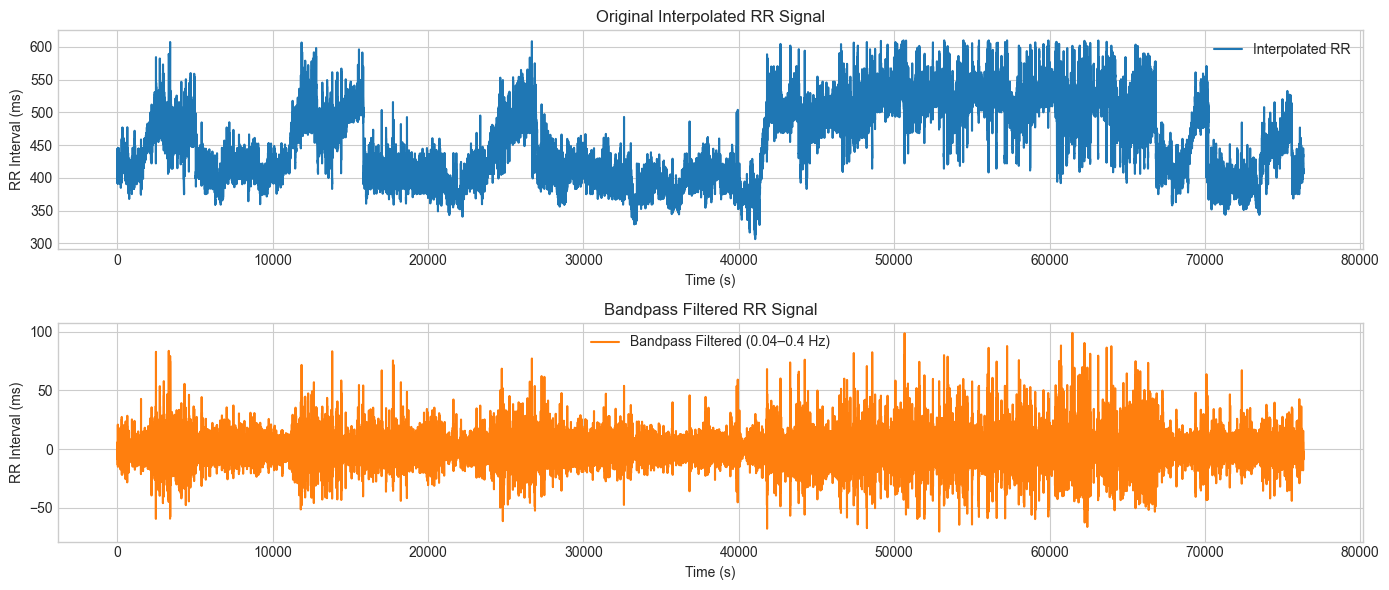

In [108]:
plt.figure(figsize=(14, 6))

# Plot the original interpolated RR signal
plt.subplot(2, 1, 1)
plt.plot(uniform_time, rr_uniform, color='tab:blue', label='Interpolated RR')
plt.title('Original Interpolated RR Signal')
plt.xlabel('Time (s)')
plt.ylabel('RR Interval (ms)')
plt.legend()
plt.grid(True)

# Plot the bandpass filtered RR signal
plt.subplot(2, 1, 2)
plt.plot(uniform_time, rr_filtered, color='tab:orange', label='Bandpass Filtered (0.04–0.4 Hz)')
plt.title('Bandpass Filtered RR Signal')
plt.xlabel('Time (s)')
plt.ylabel('RR Interval (ms)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Output explanation:**
- The top plot shows the original, interpolated RR signal (all frequencies).
- The bottom plot shows the bandpass filtered signal, highlighting only the HRV-relevant frequencies.
- Comparing these plots helps you see what information is preserved or removed by filtering.

#### FFT after bandpass filtering

Now that we've performed the bandpass filter, let's see if the FFT comes up with anything more interesting than a cluster near zero.

Let's compare before and after filtering...

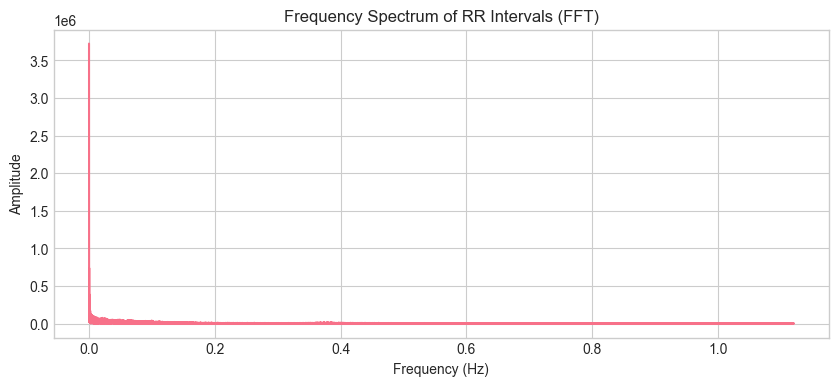

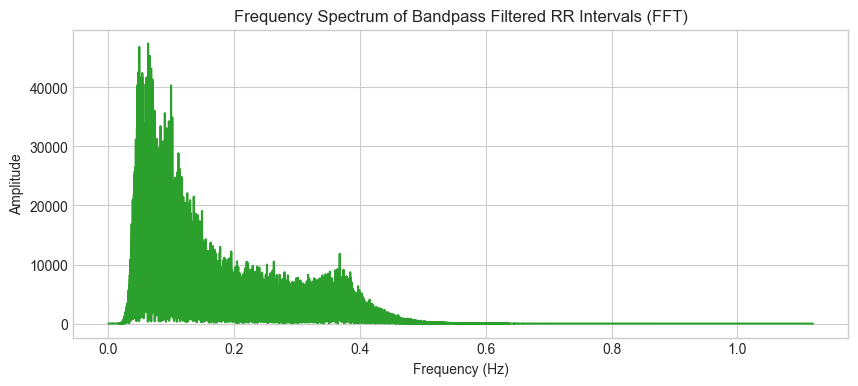

In [109]:
# Plot pre-bandpass frequency spectrum
plt.figure(figsize=(10, 4))
plt.plot(xf[1:len(xf)//2], np.abs(yf[1:len(yf)//2]))
plt.title('Frequency Spectrum of RR Intervals (FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

from scipy.fft import fft, fftfreq

# Compute FFT of the bandpass filtered signal
yf_filt = fft(rr_filtered)
xf_filt = fftfreq(len(rr_filtered), 1/sampling_rate)

plt.figure(figsize=(10, 4))
plt.plot(xf_filt[1:len(xf_filt)//2], np.abs(yf_filt[1:len(yf_filt)//2]), color='tab:green')
plt.title('Frequency Spectrum of Bandpass Filtered RR Intervals (FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

**Output explanation for the FFT plots:**

- The first FFT plot (before bandpass filtering) is dominated by a huge spike at zero frequency, known as the "DC component." This represents the mean (average) value and slow trends in the RR signal. Because this value is so large, it makes it hard to see the interesting physiological oscillations in the rest of the spectrum.
- The second FFT plot (after bandpass filtering) shows a much clearer view of the frequency content in the HRV-relevant range (0.04–0.4 Hz). The DC component and slow trends have been removed, so you can now see peaks and structure in the spectrum that correspond to actual physiological rhythms (like breathing and autonomic nervous system activity).
- This demonstrates why filtering is important: it allows you to focus on the meaningful oscillations in the data, making the FFT a much more useful tool for HRV analysis.

### 4.4 Extract Power in Frequency Bands

Now that we've filtered and transformed our signal, let's quantify how much "energy" is present in each frequency band. In HRV, these bands are linked to different physiological processes:

- **LF (Low Frequency, 0.04-0.15 Hz):** Mix of sympathetic and parasympathetic activity (think: stress and relaxation tug-of-war)
- **HF (High Frequency, 0.15-0.4 Hz):** Parasympathetic (vagal) activity (think: rest, recovery, and deep breathing)

Measuring power in these bands helps researchers and clinicians assess autonomic balance and stress resilience.

In [110]:
# Finally, let's quantify how much "energy" is in the LF and HF bands.
# These numbers are often used in research and clinical HRV analysis.

# Calculate power in LF and HF bands
lf_band = (0.04, 0.15)
hf_band = (0.15, 0.4)
power_spectrum = np.abs(yf[:len(yf)//2])**2
freqs = xf[:len(xf)//2]
lf_power = np.sum(power_spectrum[(freqs >= lf_band[0]) & (freqs < lf_band[1])])
hf_power = np.sum(power_spectrum[(freqs >= hf_band[0]) & (freqs < hf_band[1])])
print(f"LF Power (0.04-0.15 Hz): {lf_power:.2f}")
print(f"HF Power (0.15-0.4 Hz): {hf_power:.2f}")

# Output explanation:
# - LF Power: Linked to both stress and relaxation (sympathetic + parasympathetic).
# - HF Power: Linked to relaxation and deep breathing (parasympathetic).
# - Comparing these can give insight into autonomic balance.

LF Power (0.04-0.15 Hz): 1509829793348.64
HF Power (0.15-0.4 Hz): 337132041109.77


**Checkpoint:**

- Can you explain the difference between time-domain and frequency-domain features? (Hint: one looks at "how much" and the other at "how often")
- Try extracting features for a different patient! Do you see differences between age groups or individuals?
- Why might bandpass filtering be important before analyzing frequency bands?

**Common beginner mistakes:**

- Forgetting to interpolate RR intervals before FFT (FFT requires evenly spaced data)
- Misinterpreting frequency bands (make sure to use correct units—Hz, not bpm!)
- Not removing the mean before FFT (can cause a large DC component and distort results)
- Skipping bandpass filtering, which can let noise or irrelevant frequencies affect your analysis